In [22]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import pathlib

import numpy as np
import toml
import matplotlib.pyplot as plt
import pandas as pd
import pyerrors as pe
import h5py

from compute_observables import (
        compute_average_magnetisation,
        compute_average_energy,
        compute_susceptibility,
        compute_specific_heat,
        compute_binder_cumulant,
    )
from utils.h5_utils import (
    import_lattice,
    import_physical_parameter,
    import_renormalised_energy,
    import_renormalised_magnetisation,
)
from lattice_plots import (
    _generate_lattice
)

# Matplotlib plot parameters
plt.rcParams['text.usetex'] = True
plt.rcParams.update({'font.size':14, 'figure.autolayout':True})



project_name = "temperature30_0-3_1-5_l100_dim2_long"
project_path = pathlib.Path("/home/alvaro/Documents/trinity/year4/capstone/capstone-code/projects") / project_name 

def import_observable(directory: pathlib.Path, observable_name: str)->int | float:
    f = h5py.File(directory / "results.h5", "r")    
    observable = np.array(f["observables"][observable_name])
    f.close()
    return observable


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
from matplotlib import colors
project_name = "above_critical_temp_test"
project_root = pathlib.Path("/home/alvaro/Documents/trinity/year4/capstone/capstone-code/projects") 
# project_root = pathlib.Path("/home/users/romeroca/capstone-code/projects") 
parameter_combination = 0
project_path = project_root/ project_name / f"parameter-config-{parameter_combination}"
config = toml.load(project_path / "config.toml")
time = 20
lattice = import_lattice(project_path, time)

fig, ax = plt.subplots()
fig2, ax2 = plt.subplots()

angles = _generate_lattice(time,lattice, config)
y,x = np.indices(angles.shape)

u = np.cos(angles)
v = np.sin(angles)
im = ax2.imshow(
    _generate_lattice(time, import_lattice(project_path,time), config),
      cmap="hsv",
      vmin = 0,
      vmax = 2*np.pi,
      interpolation='bilinear',
      origin = "lower")
norm = colors.Normalize(vmin=0, vmax=2*np.pi)

# q = ax.quiver(x, y, u, v, angles, cmap="hsv", pivot="mid", scale = 30, norm = norm)
step = 1
q_black = ax2.quiver(
    # x[::step, ::step],
    x,
    # y[::step, ::step],
    y,
    # u[::step, ::step],
    u,
    # v[::step, ::step],
    v,
    color="black",
    pivot="mid",
    # scale=50,
    alpha=0.7,
    width=0.003,
    headwidth=3,
    headlength=4,
    headaxislength=3.5,
)
q_chat = ax.quiver(
    x[::step, ::step],
    y[::step, ::step],
    u[::step, ::step],
    v[::step, ::step],
    angles[::step, ::step],
    cmap="hsv",
    norm=norm,
    pivot="mid",
    scale=25,
    width=0.003,
    headwidth=3,
    headlength=4,
    headaxislength=3.5,
)


ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
#q = ax.quiver(x[::step], y[::step], u[::step], v[::step], angles[::step], cmap="hsv", pivot="mid", scale = 20, norm = norm)
cbar = fig.colorbar(q_chat, ax=ax, label="Spin angle (radians)")
cbar.set_ticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
cbar.set_ticklabels(["0", r"$\pi$/2", r"$\pi$", r"3$\pi$/2", r"2$\pi$"])
cbar2 = fig2.colorbar(im, ax=ax2, label="Spin angle (radians)")
cbar2.set_ticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
cbar2.set_ticklabels(["0", r"$\pi$/2", r"$\pi$", r"3$\pi$/2", r"2$\pi$"])

ax.set_aspect('equal')
ax2.set_aspect('equal')
ax.set_title(f"XY model for $J = 1$, $T = {config['physical_settings']['temperature']} / k_B$")
ax2.set_title(f"XY model for $J = 1$, $T = {config['physical_settings']['temperature']} / k_B$")
fig.set_facecolor("#ECEFF4")  
fig2.set_facecolor("#ECEFF4")  
ax.set_facecolor("#ECEFF4")    
ax2.set_facecolor("#ECEFF4")    
fig.savefig("color_arrow_plot.pdf")
fig2.savefig("lattice_arrow_plot.pdf")
plt.close()

In [ ]:
def _generate_lattice(time_step:int, df:pd.DataFrame, config:dict) -> np.array:
    L = config["physical_settings"]["L"]
    dim = config["physical_settings"]["dimension"]
    flat_grid = df.to_numpy().flatten()
    shape = tuple([int(L)] * dim)
    full_dim_grid = flat_grid.reshape(shape)
    return full_dim_grid


In [ ]:
from matplotlib import colors
from tqdm import tqdm
from matplotlib.animation import FuncAnimation
project_name = "rg_test2"
project_root = pathlib.Path("/home/alvaro/Documents/trinity/year4/capstone/capstone-code/projects") 
# project_root = pathlib.Path("/home/users/romeroca/capstone-code/projects") 
project_path = project_root/ project_name
num_dir = 0
temp_dict = {}
for dir in project_path.iterdir():
    if dir.is_dir():
        temp = import_physical_parameter(project_path /  dir, "temperature")
        temp_dict[dir] = temp
        num_dir += 1
print(temp_dict)
lattice = import_lattice(project_path / "parameter-config-0", 0)
config = toml.load(project_path / "parameter-config-0" / "config.toml")

fig, ax = plt.subplots()

im = ax.imshow(
    _generate_lattice(0, lattice, config),
      cmap="hsv",
      vmin = 0,
      vmax = 2*np.pi,
      interpolation='bilinear',
      origin = "lower")

step = 1
# q_black = ax.quiver(
#     # x[::step, ::step],
#     x,
#     # y[::step, ::step],
#     y,
#     # u[::step, ::step],
#     u,
#     # v[::step, ::step],
#     v,
#     color="black",
#     pivot="mid",
#     # scale=50,
#     alpha=0.7,
#     width=0.003,
#     headwidth=3,
#     headlength=4,
#     headaxislength=3.5,
# )
cbar = fig.colorbar(im, ax=ax, label="Spin angle (radians)")
cbar.set_ticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
cbar.set_ticklabels(["0", r"$\pi$/2", r"$\pi$", r"3$\pi$/2", r"2$\pi$"])

ax.set_aspect('equal')
fig.set_facecolor("#ECEFF4")  
ax.set_facecolor("#ECEFF4")    

frames_ps = 10
nframes = 20 * num_dir

save_path = project_root.parent / "analyze" /"output"/ "vid_dump" 
save_path.parent.mkdir(parents = True, exist_ok = True)
save_path_frame = save_path / "frames"
save_path_frame.mkdir(parents = True, exist_ok = True)
print("save path", save_path)

def update(frame):
    current_project = project_path / f"parameter-config-{frame // 20}"
    config = toml.load(current_project / "config.toml")
    ax.set_title(f"XY model for $J = 1$, $T = {config['physical_settings']['temperature']} / k_B$")
    im.set_array(_generate_lattice(frame % 20, import_lattice(current,frame % 20), config))
    # fig.savefig(save_path_frame / f"frame_{frame:03d}.png", dpi=150)
    return [im]
ani = FuncAnimation(fig, update, frames = tqdm(range(nframes), desc="Rendering"), interval = frames_ps, blit = True, cache_frame_data = False)
ani.save(save_path / f"{project_name}_temp_video.mp4", writer = "ffmpeg", fps =frames_ps, dpi = 150)

save path /home/alvaro/Documents/trinity/year4/capstone/capstone-code/analyze/output/vid_dump


Rendering: 0it [00:00, ?it/s]
/home/alvaro/Documents/trinity/year4/capstone/capstone-code/.pixi/envs/default/lib/python3.13/site-packages/matplotlib/animation.py:1762: UserWarning: Can not start iterating the frames for the initial draw. This can be caused by passing in a 0 length sequence for *frames*.

If you passed *frames* as a generator it may be exhausted due to a previous display or save.
  warnings.warn(
/home/alvaro/Documents/trinity/year4/capstone/capstone-code/.pixi/envs/default/lib/python3.13/site-packages/matplotlib/animation.py:1762: UserWarning: Can not start iterating the frames for the initial draw. This can be caused by passing in a 0 length sequence for *frames*.

If you passed *frames* as a generator it may be exhausted due to a previous display or save.
  warnings.warn(


In [ ]:
from analyze.compute_observables import *
from utils.h5_utils import (
    import_lattice_size)
import pyerrors as pe
project_name = "rg_test2"
project_root = pathlib.Path("/home/alvaro/Documents/trinity/year4/capstone/capstone-code/projects") 
# project_root = pathlib.Path("/home/users/romeroca/capstone-code/projects") 
parameter_combination = 0
project_path = project_root/ project_name 
magnetisations = []
magnetisations_obs = []
bs = [2]

for i in range(15):
    for b in bs:
        mag_arr = import_renormalised_magnetisation(project_path / f"parameter-config-{i}", b)
        N = import_lattice_size(project_path / f"parameter-config-{i}") / (b**2)
        x_mag = mag_arr[:,0] / N
        y_mag = mag_arr[:,1] / N
        magnetisation = np.sqrt(x_mag**2 + y_mag**2) 
        mag_obs = pe.Obs([magnetisation[1000:]], ["magnetisation"])
        mag_obs.gamma_method()
        magnetisations.append(np.average(magnetisation[1000:]))
        magnetisations_obs.append(mag_obs.value)
        plt.plot(magnetisation, label=f"b = {b}", alpha=1 / b)
    plt.title(f"parameter combination {i}")
    plt.legend()
    plt.show()
    plt.close()

In [2]:
def refine_inflection_points(x, d2y):
    x = np.asarray(x)
    d2y = np.asarray(d2y)

    refined_x = []
    errors = []

    for i in range(len(d2y) - 1):
        if d2y[i] == 0:
            refined_x.append(x[i])
            errors.append(0)
        elif d2y[i] * d2y[i+1] < 0:
            # Linear interpolation to find zero crossing
            x0, x1 = x[i], x[i+1]
            y0, y1 = d2y[i], d2y[i+1]

            x_zero = x0 - y0 * (x1 - x0) / (y1 - y0)

            refined_x.append(x_zero)

            # Error ≈ half interval width
            errors.append(abs(x1 - x0) / 2)

    return np.array(refined_x), np.array(errors)

Inflection points: [3.14160517 6.28320183 9.42479215]
Estimated error: [0.05050505 0.05050505 0.05050505]
Inflection indices: [31 62 93]
Inflection x values: [3.13131313 6.26262626 9.39393939]
Inflection y values: [ 0.01027934 -0.0205576   0.03083368]


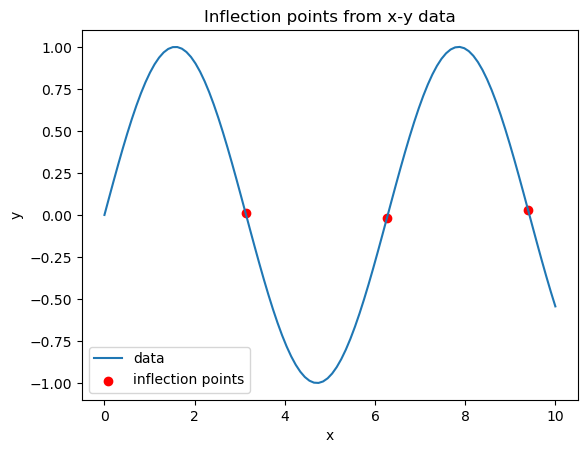

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def find_inflection_points_xy(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) != len(y):
        raise ValueError("x and y must have the same length")

    if len(x) < 3:
        raise ValueError("Need at least 3 points")

    if np.any(np.diff(x) == 0):
        raise ValueError("x values must be unique (no duplicates)")

    # First derivative
    dy = np.gradient(y, x)

    # Second derivative
    d2y = np.gradient(dy, x)

    # Sign change in second derivative
    indices = np.where(np.diff(np.sign(d2y)) != 0)[0]

    return x[indices], y[indices], indices, d2y


# Example data
x = np.linspace(0, 10, 100)
y = np.sin(x)
dy = np.gradient(y, x)
d2y = np.gradient(dy, x)

x_inf, err = refine_inflection_points(x, d2y)

print("Inflection points:", x_inf)
print("Estimated error:", err)

x_inf, y_inf, idx_inf, d2y = find_inflection_points_xy(x, y)


print("Inflection indices:", idx_inf)
print("Inflection x values:", x_inf)
print("Inflection y values:", y_inf)

plt.plot(x, y, label="data")
plt.scatter(x_inf, y_inf, color="red", label="inflection points")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Inflection points from x-y data")
plt.show()

In [2]:
import pandas as pd
df = pd.read_csv("/home/alvaro/Documents/trinity/year4/capstone/code_outputs/3003outputs/20260330_30t0_8-1_2_4l16-512_dim2_10-3sweeps_observables.csv")

In [8]:
df.describe()

,temperature,L,magnetisation_value,magnetisation_error,magnetisation_tau_int,energy_value,energy_error,energy_tau_int,susceptibility_value,susceptibility_error,...,energy_per_spin_tau_int,susceptibility_per_spin_value,susceptibility_per_spin_error,susceptibility_per_spin_tau_int,specific_heat_per_spin_value,specific_heat_per_spin_error,specific_heat_per_spin_tau_int,cluster_susceptibility_value,cluster_susceptibility_error,cluster_susceptibility_tau_int
count,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,3.600000e+02,3.600000e+02,...,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000
mean,0.991648,170.133333,0.360512,0.002577,0.890329,-65918.914988,19.865535,3.763662,1.159106e+07,6.948788e+05,...,3.763662,90.568545,5.483093,0.628029,1.247774,0.107986,1.506503,6784.399995,130.659343,0.862611
std,0.118411,145.581244,0.238838,0.001532,0.349874,95285.812664,30.006545,5.269349,4.386807e+07,2.333172e+06,...,5.269349,205.319628,11.214242,0.155882,0.304574,0.097616,1.949474,16149.885057,303.612645,1.336603
min,0.800000,16.000000,0.012329,0.000237,0.501248,-381504.155162,0.820171,1.299887,1.305524e+02,9.486838e+00,...,1.299887,0.509970,0.037058,0.501248,0.701026,0.042758,0.611570,28.913840,0.040862,0.501248
25%,0.882759,40.000000,0.102271,0.001580,0.536017,-97813.386140,4.326011,2.254249,2.660834e+04,1.733677e+03,...,2.254249,9.595038,0.563201,0.502497,1.020268,0.079004,1.056057,93.497141,1.405428,0.506990
50%,0.993103,100.000000,0.411987,0.002220,0.852665,-14950.909859,10.249388,2.840695,3.592066e+05,2.300540e+04,...,2.840695,21.165287,1.281226,0.569616,1.260288,0.096791,1.307811,491.608181,8.683833,0.703801
75%,1.089655,256.000000,0.573894,0.003617,1.139582,-2404.948439,27.184543,3.738297,4.643129e+06,2.789462e+05,...,3.738297,81.816125,5.365608,0.696009,1.419409,0.119741,1.613804,3367.848315,70.908434,0.909297
max,1.200000,500.000000,0.764855,0.006722,2.033188,-274.448384,367.559418,69.782348,4.729728e+08,2.291855e+07,...,69.782348,1891.891038,91.674213,1.340344,3.563755,1.777595,36.434576,99178.753882,1757.673711,23.061466


In [22]:
plt.close()
for z_value, group in df.groupby("L"):
    group = group.sort_values("temperature")
    plt.plot(group["temperature"], group["magnetisation_value"], 'o-', label=f"L= {z_value}")
    plt.legend()
plt.savefig("magnetisation_vs_temp.pdf")

In [3]:
from scipy.optimize import curve_fit

def tanh_model(t, amplitude, centre, scale, offset):
    t = np.asarray(t, dtype=float)
    return amplitude * np.tanh((t - centre) / scale) + offset

def fit_tanh_vs_L(L, y, yerr=None):
    L = np.asarray(L, dtype=float)
    y = np.asarray(y, dtype=float)

    if L.shape != y.shape:
        raise ValueError("L and y must have the same shape")
    if L.size < 4:
        raise ValueError("Need at least 4 points for a 4-parameter tanh fit")

    order = np.argsort(L)
    L = L[order]
    y = y[order]

    amplitude_guess = 0.5 * (np.max(y) - np.min(y))
    if np.isclose(amplitude_guess, 0.0):
        amplitude_guess = 1.0

    centre_guess = np.median(L)
    scale_guess = max((np.max(L) - np.min(L)) / 4.0, 1e-6)
    offset_guess = np.mean(y)
    initial_guess = [amplitude_guess, centre_guess, scale_guess, offset_guess]

    fit_kwargs = {"p0": initial_guess, "maxfev": 10000}
    if yerr is not None:
        yerr = np.asarray(yerr, dtype=float)
        if yerr.shape != y.shape:
            raise ValueError("yerr must have the same shape as y")
        yerr = yerr[order]
        fit_kwargs["sigma"] = yerr
        fit_kwargs["absolute_sigma"] = True

    params, covariance = curve_fit(tanh_model, L, y, **fit_kwargs)
    return params, covariance

def plot_tanh_fit_vs_L(L, y, yerr=None, ax=None, data_label="data", fit_label="tanh fit"):
    params, covariance = fit_tanh_vs_L(L, y, yerr=yerr)
    L = np.asarray(L, dtype=float)
    y = np.asarray(y, dtype=float)
    order = np.argsort(L)
    L = L[order]
    y = y[order]

    if yerr is not None:
        yerr = np.asarray(yerr, dtype=float)[order]

    if ax is None:
        _, ax = plt.subplots()

    ax.errorbar(L, y, yerr=yerr, fmt="o", label=data_label)
    L_fit = np.linspace(np.min(L), np.max(L), 300)
    ax.plot(L_fit, tanh_model(L_fit, *params), "--", label=fit_label)
    ax.set_xlabel("L")
    ax.legend()
    return ax, params, covariance


In [4]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 16,        # default text size
    "axes.titlesize": 19,   # title size
    "axes.labelsize": 18,   # axis labels
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16
})

NameError: name 'plot_tanh_fit_vs_L' is not defined

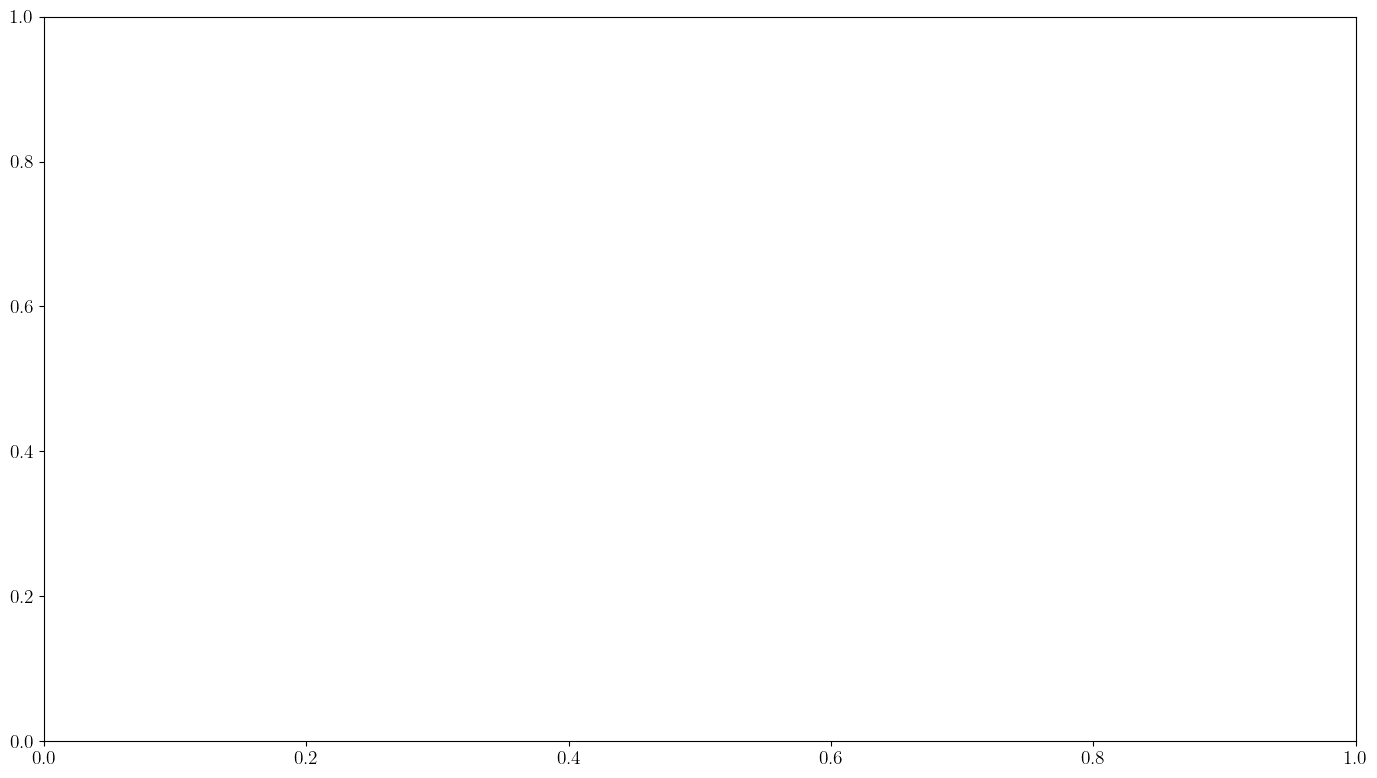

In [35]:
from matplotlib import ticker


observable_col = "magnetisation_value"
error_col = "magnetisation_error"

fit_df = df[["temperature", "L", observable_col, error_col]].dropna()

if fit_df.empty:
    raise ValueError("No valid rows found for the fit")

fig, axs = plt.subplots(figsize=(14, 8))
fit_results = {}
fit_error = {}

for L_value, group in fit_df.groupby("L"):
    group = group.sort_values("temperature")
    if len(group) < 4:
        print(f"Skipping L={L_value}: need at least 4 points for tanh fit")
        continue

    temperatures = group["temperature"].to_numpy()
    magnetisation = group[observable_col].to_numpy()
    errors = group[error_col].to_numpy()

    axs, params, covariance = plot_tanh_fit_vs_L(
        temperatures,
        magnetisation,
        yerr=errors,
        ax=axs,
        data_label=fr"$L = {L_value}$ data",
        fit_label=fr"$L = {L_value}$ tanh fit",
    )
    fit_results[L_value] = params
    perr = np.sqrt(np.diag(covariance))
    print(perr)
    fit_error[L_value] = perr

axs.set_xlabel("Temperature")
axs.set_ylabel("Magnetisation")
axs.set_title(r"Magnetisation vs Temperature with tanh fits")

l_values = []
t_c_array = []
t_c_error = []
for L_value, params in fit_results.items():
    l_values.append(L_value)
    t_c_array.append(params[1]) 
    t_c_error.append(fit_error[L_value][1])
    print(f"L={L_value}: [amplitude, centre, scale, offset] = {params}")
    # Make latex formatter
latex_formatter = ticker.FuncFormatter(lambda x, pos: f'${x:g}$')

# Apply formatting
axs.xaxis.set_major_formatter(latex_formatter)
axs.yaxis.set_major_formatter(latex_formatter)
# axs.yaxis.set_minor_formatter(latex_formatter)
# axs.xaxis.set_minor_formatter(latex_formatter)
handles, labels = axs.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
# axs.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.1,1.05), fancybox = True, shadow = True)
box = axs.get_position()
axs.set_position([box.x0, box.y0 + box.height * 0.1,
                    box.width, box.height * 0.9])

# Put a legend below current axis
axs.legend(by_label.values(), by_label.keys(),loc='upper center', bbox_to_anchor=(0.5, -0.1),
            fancybox=True, shadow=True, ncol=5)

axs.grid()
axs.minorticks_on()
axs.tick_params(axis='both', which='major', direction='in', length=7, top=True, right = True)
axs.tick_params(axis='both', which='minor', direction='in', length=4, top=True, right = True)


fig.savefig("magnetisation_vs_temperature_tanh_fit_by_L.pdf",bbox_inches = "tight")
plt.close()

fig, ax = plt.subplots(figsize=(8, 6))

# now fit a line to extrapolate to infinite L
def linear_model(x, a, b):
    return a * x + b

p0 = [1.0, 0.0]  # Initial guess for slope and intercept
omit_last = 1
l_values_og = l_values
l_values = l_values[omit_last:]
t_c_array = t_c_array[omit_last:]
t_c_error = t_c_error[omit_last:]
print("l values for fit:", l_values)
print("t_c values for fit:", t_c_array)
values_to_fit = 1 / np.log(np.array(l_values))**2
popt, pcov = curve_fit(linear_model, values_to_fit, t_c_array, p0=p0)
x_fit = np.linspace(-1, max(values_to_fit), 100)
y_fit = linear_model(x_fit, *popt)
fig.set_facecolor("#ECEFF4")  
ax.set_facecolor("#ECEFF4")    
ax.errorbar(values_to_fit, t_c_array, yerr=t_c_error, fmt="o-", capsize=5)
ax.plot(x_fit, y_fit, "--", label="Linear fit")
ax.set_xlabel(r"$\ln(a/L)^2$", fontsize=18)
ax.set_ylabel(r"$T_c(L)$", fontsize=18)
    # Make latex formatter
latex_formatter = ticker.FuncFormatter(lambda x, pos: f'${x:g}$')

    # Apply formatting
ax.xaxis.set_major_formatter(latex_formatter)
ax.yaxis.set_major_formatter(latex_formatter)
# ax.yaxis.set_minor_formatter(latex_formatter)
# ax.xaxis.set_minor_formatter(latex_formatter)

ax.legend()
ax.grid()
ax.minorticks_on()
ax.tick_params(axis='both', which='major', direction='in', length=7, top=True, right = True)
ax.tick_params(axis='both', which='minor', direction='in', length=4, top=True, right = True)
# i want to set this so that you can see the intercept with the y axis
ax.set_xlim(-0.01, max(values_to_fit)*1.1)
# ax.set_title(r"Extrapolation of $T_c(L)$ to infinite $L$")
ax.legend()
plt.tight_layout()
fig.savefig("t_c_extrapolation.pdf")
print(f"Extrapolated T_c at infinite L: {popt[1]} ± {np.sqrt(pcov[1,1])}")


In [28]:
df.iloc[8,0]

np.float64(0.896551724137931)

In [41]:
df

,temperature,L,magnetisation_value,magnetisation_error,magnetisation_tau_int,energy_value,energy_error,energy_tau_int,susceptibility_value,susceptibility_error,...,energy_per_spin_tau_int,susceptibility_per_spin_value,susceptibility_per_spin_error,susceptibility_per_spin_tau_int,specific_heat_per_spin_value,specific_heat_per_spin_error,specific_heat_per_spin_tau_int,cluster_susceptibility_value,cluster_susceptibility_error,cluster_susceptibility_tau_int
0,0.800000,16.0,0.764855,0.002277,1.299250,-392.870894,0.873870,2.656177,1.305524e+02,9.486838,...,2.656177,0.509970,0.037058,0.951077,0.701026,0.042758,0.735394,177.229799,2.399447,0.503745
1,0.813793,16.0,0.751068,0.002290,1.134132,-386.339693,0.825911,1.910601,1.487043e+02,10.510075,...,1.910601,0.580876,0.041055,0.811977,0.841290,0.055622,0.951164,168.366604,2.312648,0.510929
2,0.827586,16.0,0.747899,0.002974,1.547959,-384.102952,0.944240,2.220091,1.807528e+02,18.814680,...,2.220091,0.706066,0.073495,0.588173,0.915050,0.077210,1.500107,162.414912,2.261354,0.501248
3,0.827586,16.0,0.754037,0.002007,0.805623,-386.436875,0.962983,2.613725,1.582385e+02,12.417255,...,2.613725,0.618119,0.048505,0.566374,0.808403,0.069906,1.289369,162.639653,2.339321,0.566852
4,0.841379,16.0,0.748023,0.002493,1.182299,-383.779436,1.029866,2.698918,1.635751e+02,12.508157,...,2.698918,0.638965,0.048860,0.721643,0.866295,0.079839,1.318944,158.290504,2.227189,0.501248
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,1.131034,500.0,0.016466,0.000305,0.512613,-283305.295231,58.987130,3.262556,3.997599e+06,218289.371761,...,3.262556,15.990396,0.873157,0.502497,1.332239,0.113704,1.467532,61.859586,0.109641,0.884798
356,1.144828,500.0,0.015249,0.000271,0.501248,-278838.607528,53.578571,2.633575,3.198120e+06,173848.247134,...,2.633575,12.792479,0.695393,0.501248,1.329027,0.103676,1.272747,51.923206,0.090068,0.958112
357,1.158621,500.0,0.014424,0.000277,0.503745,-274353.085342,56.352966,2.811650,3.287936e+06,185192.419630,...,2.811650,13.151746,0.740770,0.501248,1.344520,0.092776,1.031511,44.007611,0.064916,0.872678
358,1.172414,500.0,0.012916,0.000258,0.558379,-270006.603407,55.195827,2.658708,2.541384e+06,146309.537631,...,2.658708,10.165538,0.585238,0.507247,1.332163,0.109248,1.285971,37.849918,0.052035,0.907291


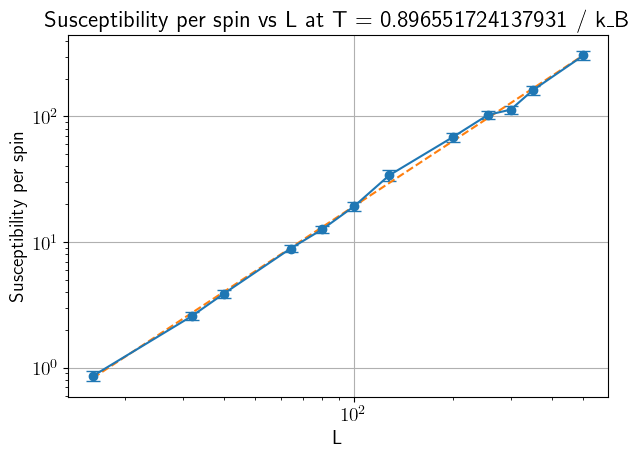

In [ ]:
from scipy.optimize import curve_fit
reduced_df = df[df["temperature"] == df.iloc[8, 0]]
xaxis = df["L"].unique()
yaxis = reduced_df["susceptibility_per_spin_value"].to_numpy() * df.iloc[8,0]
yerr = reduced_df["susceptibility_per_spin_error"].to_numpy()
fig, ax = plt.subplots()
ax.errorbar(xaxis, yaxis, yerr=yerr, fmt="o-", capsize=5)
ax.set_xlabel("L")
ax.set_ylabel("Susceptibility per spin")
ax.set_title(f"Susceptibility per spin vs L at T = {df.iloc[8, 0]} / k_B")
x_to_fit = np.log(xaxis)
y_to_fit = np.log(yaxis)
popt, pcov = curve_fit(linear_model, x_to_fit, y_to_fit)
ax.plot(xaxis, np.exp(linear_model(x_to_fit, *popt)), "--", label="Power-law fit")
ax.loglog()
ax.grid()
plt.show()
plt.close()